Per model: map tree cover in 2015, 2016, and 2100. (first thing)

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from cartopy.util import add_cyclic_point

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

from matplotlib.backends.backend_pdf import PdfPages


logger = logging.getLogger(__name__)

In [2]:
#run map_cpools.ipynb

In [3]:
def jules_fracs(LU_SCENARIO,ssp,endyear,aggregate_pfts=True):
    
    var = 'landCoverFrac'
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    #ssp = 'ssp126'
    #esm = 'ukesm1-0-ll'
    path = '' 
    
    nclim = len(ESMS)
    years = np.arange(2015,2101)
    ntime = len(years)
    
    grouped_pfts = ['Woody','Grasses','BE Crops']
    ngroups = len(grouped_pfts)
    
    ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/mask_latlon2d.nc', 'r')
    lons = ncfile1.variables['lon']
    lats = ncfile1.variables['lat']
    nlon = len(lons)
    nlat = len(lats)
    land_fraction = ncfile1.variables['land_sea_mask']

    if aggregate_pfts==True:
        fracs_2015 = np.zeros([3,ngroups+1,nlat,nlon])
        fracs_end = np.zeros([3,ngroups+1,nlat,nlon])
        plotdata = np.zeros([3,ntime,ngroups+1])
    else:
        fracs_2015 = np.empty([3,npft+1,nlat,nlon])
        fracs_end = np.empty([3,npft+1,nlat,nlon])
        plotdata = np.empty([3,ntime,npft+1])

        
    if LU_SCENARIO == 'nolucbio' or LU_SCENARIO == 'nattobio' or LU_SCENARIO == 'agtobio':
        npft = 14
        pfts = ['BET-Tr', 'BET-Te', 'BDT', 'NET', 
                'NDT','C3G(nat)', 'C3G(crop)', 'C3G(past)', 
                'C4G(nat)','C4G(crop)', 'C4G(past)', 'ESh', 
                'DSh', 'Misc(bio)']
        grouped_indx = [0,0,0,0,0,1,1,1,1,1,1,0,0,2]
    else:
        npft = 22
        pfts = ['BET-Tr', 'BET-Te', 'BDT', 'NET', 
                'NDT','C3G(nat)', 'C3G(crop)', 'C3G(past)', 
                'C4G(nat)','C4G(crop)', 'C4G(past)', 'ESh', 
                'DSh', 'BET-Tr(bio)', 'BET-Te(bio)', 'BDT(bio)', 
                'NET(bio)', 'NDT(bio)','C3G(bio)', 'C4G(bio)',
                'ESh(bio)', 'DSh(bio)']
        grouped_indx = [0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,0,0]
    
    ncfile2=Dataset('/bdd/ESM2025/WP10/jules/jules_'+ESMS[0]+'_'+ssp+'_'+LU_SCENARIO+\
                    '_landCoverFrac.monthly.nc', 'r')
    fracs = ncfile2.variables['landCoverFrac'][::12,0,:,:]
    weights = np.empty_like(fracs)
    for kk in range(nlat):
        weights[:,kk,:] = np.cos(np.deg2rad(lats[kk]))    
    del fracs   
    
    model_i=0
    for esm in ESMS:    
        ncfile2=Dataset('/bdd/ESM2025/WP10/jules/jules_'+esm+'_'+ssp+'_'+LU_SCENARIO+\
                        '_landCoverFrac.monthly.nc', 'r')
        print('/bdd/ESM2025/WP10/jules/jules_'+esm+'_'+ssp+'_'+LU_SCENARIO+\
                        '_landCoverFrac.monthly.nc')
        for ij in range(npft):
            #time, lat, lon
            fracs = ncfile2.variables['landCoverFrac'][::12,ij,:,:]

            if aggregate_pfts==True:
                ipft = grouped_indx[ij]
                plotdata[model_i,:,ipft] = plotdata[model_i,:,ipft] + \
                                           np.mean(fracs * weights, axis=(1,2))
                fracs_2015[model_i,ipft,:,:] = fracs_2015[model_i,ipft,:,:] + fracs[0,:,:]
                fracs_end[model_i,ipft,:,:] = fracs_end[model_i,ipft,:,:] + \
                                              fracs[endyear-2015,:,:]
            else:
                plotdata[model_i,:,ij] = np.mean(fracs * weights, axis=(1,2))
                fracs_2015[model_i,ij,:,:] = fracs[0,:,:]
                fracs_end[model_i,ij,:,:] = fracs[endyear-2015,:,:]        
            del fracs

        print(np.min(fracs_2015[model_i,0,:,:]),np.max(fracs_2015[model_i,0,:,:]))
        #BARE SOIL   
        fracs = ncfile2.variables['landCoverFrac'][::12,npft+2,:,:]
        if aggregate_pfts==True:
            plotdata[model_i,:,ngroups] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,ngroups,:,:] = fracs[0,:,:]
            fracs_end[model_i,ngroups,:,:] = fracs[endyear-2015,:,:]
        else:
            plotdata[model_i,:,npft] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,npft,:,:] = fracs[0,:,:]
            fracs_end[model_i,npft,:,:] = fracs[endyear-2015,:,:]             
        del fracs
        model_i+=1
    
    return np.mean(fracs_2015,axis=0), np.mean(fracs_end,axis=0), np.mean(plotdata,axis=0)
    

In [4]:
def get_lsm_data(lsm):
    if lsm=='jules':
        ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/mask_latlon2d.nc', 'r')
        lons = ncfile1.variables['lon']
        lats = ncfile1.variables['lat']
        temparray = ncfile1.variables['land_sea_mask']
        
        land_fraction=np.empty_like(temparray)
        land_fraction[:,:90] = temparray[:,90:]
        land_fraction[:,90:] = temparray[:,:90]
        del(temparray)        
    elif lsm=='clm':
        ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/clm_landfrac.nc', 'r')
        lons = ncfile1.variables['lon']
        lats = ncfile1.variables['lat']
        land_fraction = ncfile1.variables['landfrac']
    elif lsm=='orchidee':
        ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/orchidee_oceanCoverFrac_notime.nc', 'r')
        lons = ncfile1.variables['longitude']
        lats = ncfile1.variables['latitude']
        #0=ocean; 1=land
        ocean_frac = ncfile1.variables['oceanCoverFrac']
        ones = np.ones_like(ocean_frac)
        land_fraction = ones - ocean_frac        
        del(ones, ocean_frac)
    elif lsm=='jsbach':
        ncfile1 = Dataset('/bdd/ESM2025/WP10/jsbach/hist/JSBACH3_ukesm1-0-ll_hist_hist_oceanCoverFrac.once.nc', 'r')
        lons = ncfile1.variables['lon']
        lats = ncfile1.variables['lat']
        #lats=np.flip(lats,0)
            
        #0=ocean; 1=land
        ocean_frac = ncfile1.variables['oceanCoverFrac']
        ones = np.ones_like(ocean_frac)
        land_fraction = ones - ocean_frac  
        del(ones, ocean_frac)
    else:
        print('Incorrect name for LSM in get_lsm_data')

    return land_fraction, lons, lats

In [5]:
def jsbach_fracs(LU_SCENARIO,ssp,endyear,aggregate_pfts=True):
    
    var = 'landCoverFrac'
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    #ssp = 'ssp126'
    #esm = 'ukesm1-0-ll'
    path = '' 
    
    nclim = len(ESMS)
    years = np.arange(2015,2100)
    ntime = len(years)
    
    grouped_pfts = ['Woody','Grasses','BE Crops']
    ngroups = len(grouped_pfts)
    
    ncfile1 = Dataset('/bdd/ESM2025/WP10/jsbach/hist/JSBACH3_ukesm1-0-ll_hist_hist_oceanCoverFrac.once.nc',\
                      'r')
    lons = ncfile1.variables['lon']
    lats = ncfile1.variables['lat']
    nlon = len(lons)
    nlat = len(lats)

    fracs_2015 = np.zeros([3,ngroups+1,nlat,nlon])
    fracs_end = np.zeros([3,ngroups+1,nlat,nlon])
    plotdata = np.zeros([3,ntime,ngroups+1])

    npft = 12
    # Trees
    grouped_indx = np.empty(npft,dtype=np.int32)
    grouped_indx[0:npft] = -999    
    grouped_indx[0:6] = 0
    # Grasses
    grouped_indx[6:11] = 1
    # Bioenergy
    grouped_indx[11] = 2
    
    ncfile2=Dataset('/bdd/ESM2025/WP10/jsbach/'+LU_SCENARIO+'/'+\
                    'JSBACH3_'+ESMS[0]+'_'+ssp+'_'+LU_SCENARIO+'_landCoverFrac.monthly.nc', 'r')
    fracs = ncfile2.variables['landCoverFrac'][::12,0,:,:]
    weights = np.empty_like(fracs)
    for kk in range(nlat):
        weights[:,kk,:] = np.cos(np.deg2rad(lats[kk]))    
    del fracs   
    
    model_i=0
    for esm in ESMS:    
        ncfile2=Dataset('/bdd/ESM2025/WP10/jsbach/'+LU_SCENARIO+'/'+\
                    'JSBACH3_'+esm+'_'+ssp+'_'+LU_SCENARIO+'_landCoverFrac.monthly.nc', 'r')
        
        for ij in range(npft):
            #time, lat, lon
            fracs = ncfile2.variables['landCoverFrac'][::12,ij,:,:]
            #print(grouped_indx[ij],ij)
            
            if grouped_indx[ij]>=0:
                ipft = grouped_indx[ij]
                plotdata[model_i,:,ipft] = plotdata[model_i,:,ipft] + \
                                           np.mean(fracs * weights, axis=(1,2))
                fracs_2015[model_i,ipft,:,:] = fracs_2015[model_i,ipft,:,:] + fracs[0,:,:]
                fracs_end[model_i,ipft,:,:] = fracs_end[model_i,ipft,:,:] + \
                                                  fracs[endyear-2015,:,:]   
            del fracs

        #print(np.min(fracs_2015[model_i,0,:,:]),np.max(fracs_2015[model_i,0,:,:]))
        #NO BARE SOIL   
        model_i+=1
    
    return np.mean(fracs_2015,axis=0), np.mean(fracs_end,axis=0), np.mean(plotdata,axis=0)
    

In [6]:
def orchidee_fracs(LU_SCENARIO,ssp,endyear,aggregate_pfts=True):
    
    var = 'landCoverFrac'
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    #ssp = 'ssp126'
    #esm = 'ukesm1-0-ll'
    path = '' 
    
    nclim = len(ESMS)
    years = np.arange(2015,2101)
    ntime = len(years)
    
    grouped_pfts = ['Woody','Grasses','BE Crops']
    ngroups = len(grouped_pfts)
    
    ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/orchidee_oceanCoverFrac_notime.nc','r')
    lons = ncfile1.variables['longitude']
    lats = ncfile1.variables['latitude']
    nlon = len(lons)
    nlat = len(lats)

    fracs_2015 = np.zeros([3,ngroups+1,nlat,nlon])
    fracs_end = np.zeros([3,ngroups+1,nlat,nlon])
    plotdata = np.zeros([3,ntime,ngroups+1])

    npft = 15
    # Trees
    grouped_indx = np.empty(npft,dtype=np.int32)
    grouped_indx[0:15] = -999    
    grouped_indx[1:9] = 0
    # Grasses
    grouped_indx[9:15] = 1

    ncfile2=Dataset('/bdd/ESM2025/WP10/orchidee/'+ESMS[0]+'_'+ssp+'_'+LU_SCENARIO+'/'+\
                    'orchidee_'+ESMS[0]+'_'+ssp+'_'+LU_SCENARIO+'_landCoverFrac.nc', 'r')
    fracs = ncfile2.variables['landCoverFrac'][:,0,:,:]
    weights = np.empty_like(fracs)
    for kk in range(nlat):
        weights[:,kk,:] = np.cos(np.deg2rad(lats[kk]))    
    del fracs   
    
    model_i=0
    for esm in ESMS:    
        ncfile2=Dataset('/bdd/ESM2025/WP10/orchidee/'+esm+'_'+ssp+'_'+LU_SCENARIO+'/'+\
                    'orchidee_'+esm+'_'+ssp+'_'+LU_SCENARIO+'_landCoverFrac.nc', 'r')
        
        for ij in range(npft):
            #time, lat, lon
            fracs = ncfile2.variables['landCoverFrac'][:,ij,:,:]
            #print(grouped_indx[ij],ij)
            
            if grouped_indx[ij]>=0:
                ipft = grouped_indx[ij]
                plotdata[model_i,:,ipft] = plotdata[model_i,:,ipft] + \
                                           np.mean(fracs * weights, axis=(1,2))
                fracs_2015[model_i,ipft,:,:] = fracs_2015[model_i,ipft,:,:] + fracs[0,:,:]
                fracs_end[model_i,ipft,:,:] = fracs_end[model_i,ipft,:,:] + \
                                              fracs[endyear-2015,:,:]   
            del fracs

        print(np.min(fracs_2015[model_i,0,:,:]),np.max(fracs_2015[model_i,0,:,:]))
        #BARE SOIL   
        fracs = ncfile2.variables['landCoverFrac'][:,0,:,:]
        if aggregate_pfts==True:
            plotdata[model_i,:,ngroups] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,ngroups,:,:] = fracs[0,:,:]
            fracs_end[model_i,ngroups,:,:] = fracs[endyear-2015,:,:]
        else:
            plotdata[model_i,:,npft] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,npft,:,:] = fracs[0,:,:]
            fracs_end[model_i,npft,:,:] = fracs[endyear-2015,:,:]             
        del fracs
        model_i+=1
    
    return np.mean(fracs_2015,axis=0), np.mean(fracs_end,axis=0), np.mean(plotdata,axis=0)
    

In [7]:
def clm_fracs(LU_SCENARIO,ssp,endyear,aggregate_pfts=True):
    
    var = 'landCoverFrac'
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    #ssp = 'ssp126'
    #esm = 'ukesm1-0-ll'
    path = '' 
    
    nclim = len(ESMS)
    years = np.arange(2015,2101)
    ntime = len(years)
    
    grouped_pfts = ['Woody','Grasses','BE Crops']
    ngroups = len(grouped_pfts)
    
    ncfile1 = Dataset('/bdd/ESM2025/WP10/analysis/scripts/clm_landfrac.nc','r')
    lons = ncfile1.variables['lon']
    lats = ncfile1.variables['lat']
    nlon = len(lons)
    nlat = len(lats)
    land_fraction = ncfile1.variables['landfrac']

    fracs_2015 = np.zeros([3,ngroups+1,nlat,nlon])
    fracs_end = np.zeros([3,ngroups+1,nlat,nlon])
    plotdata = np.zeros([3,ntime,ngroups+1])

    npft = 79
    # Trees
    grouped_indx = np.empty(npft,dtype=np.int32)
    grouped_indx[0:79] = -999    
    grouped_indx[1:12] = 0
    # Grasses
    grouped_indx[12:15] = 1
    grouped_indx[17:21] = 1
    grouped_indx[23:25] = 1
    grouped_indx[61:63] = 1
    grouped_indx[67:69] = 1
    grouped_indx[75:79] = 1
    

    #All of these indices have non-zero values in 2015 in the no luc file (used ukesm ssp126 as an example):
    #17,18,19,20,23,24,61,62,67,68,75,76,77,78
    # Bioenergy
    grouped_indx[71:75] = 2

    ncfile2=Dataset('/bdd/ESM2025/WP10/clm/clm_'+ESMS[0]+'_'+ssp+'_'+LU_SCENARIO+\
                    '_landCoverFrac.monthly.nc', 'r')
    fracs = ncfile2.variables['landCoverFrac'][::12,0,:,:]
    weights = np.empty_like(fracs)
    for kk in range(nlat):
        weights[:,kk,:] = np.cos(np.deg2rad(lats[kk]))    
    del fracs   
    
    model_i=0
    for esm in ESMS:    
        ncfile2=Dataset('/bdd/ESM2025/WP10/clm/clm_'+esm+'_'+ssp+'_'+LU_SCENARIO+\
                        '_landCoverFrac.monthly.nc', 'r')
        print('/bdd/ESM2025/WP10/clm/clm_'+esm+'_'+ssp+'_'+LU_SCENARIO+\
                        '_landCoverFrac.monthly.nc')
        for ij in range(npft):
            #time, lat, lon
            # CLM FILES JUST HAVE ONE VALUE FOR TIME
            fracs = ncfile2.variables['landCoverFrac'][:,ij,:,:]
            
            if grouped_indx[ij]>=0:
                ipft = grouped_indx[ij]
                plotdata[model_i,:,ipft] = plotdata[model_i,:,ipft] + \
                                           np.mean(fracs * weights, axis=(1,2))
                fracs_2015[model_i,ipft,:,:] = fracs_2015[model_i,ipft,:,:] + fracs[0,:,:]
                fracs_end[model_i,ipft,:,:] = fracs_end[model_i,ipft,:,:] + \
                                              fracs[-1,:,:]   
            del fracs

        print(np.min(fracs_2015[model_i,0,:,:]),np.max(fracs_2015[model_i,0,:,:]))
        #BARE SOIL   
        fracs = ncfile2.variables['landCoverFrac'][::12,0,:,:]
        if aggregate_pfts==True:
            plotdata[model_i,:,ngroups] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,ngroups,:,:] = fracs[0,:,:]
            fracs_end[model_i,ngroups,:,:] = fracs[-1,:,:]
        else:
            plotdata[model_i,:,npft] = np.mean(fracs * weights, axis=(1,2))
            fracs_2015[model_i,npft,:,:] = fracs[0,:,:]
            fracs_end[model_i,npft,:,:] = fracs[-1,:,:]             
        del fracs
        model_i+=1

    if aggregate_pfts == True: fracs_2015[:,2,:,:].fill(0)

    #print(LU_SCENARIO,ssp,plotdata[:,:,2])
    return np.mean(fracs_2015,axis=0), np.mean(fracs_end,axis=0), np.mean(plotdata,axis=0)
    

In [8]:
def make_map1(lsm,label,axs,axi,lon,lats,input_array): 
    '''
    Make the map of 2015 land cover.

    Inputs:
    lsm: Name of the land surface model.
    label: should be noluc, nolucbio, or nolucaff
    axs: The axis 
    Axi: Index of the axis
    lons: Longitude, should be len N
    lats: Latitudes, should be len M
    mapdata: Data array, should be size (M,N)
    '''
    
    #Each variable needs four maps (one for each land model)
    mapdata,lons = add_cyclic_point(input_array,lon)
    
#    if year=='delta':
#        clevs = np.arange(-0.20,0.25,0.05)
#        colormap='BrBG'
#    else:
    clevs = np.arange(0.01,1.01,0.1)
    colormap='summer_r'
    
    # I don't know how to do this cleanly
#    nlats = len(lats)
#    for i in range(nlats):
#        print(i,lats[i],np.min(mapdata[i,:]),np.max(mapdata[i,:]))
        
    if lsm=='JSBACH':
        latSouth=3
        latNorth=79
        clon=0.0
    elif lsm=='JULES':
        latSouth=16 #north of 58S
        latNorth=88 #south of 86N
        clon=180
    elif lsm=='CLM':
        latSouth=17
        latNorth=92
        clon=0.0
    elif lsm=='ORCHIDEE':
        latSouth=16
        latNorth=88
        clon=0.0   
        
    cs=axs[axi].contourf(lons,lats,mapdata, clevs,
                      transform = ccrs.PlateCarree(central_longitude=clon),
                      cmap=colormap,extend='max')              
    axs[axi].set_title(lsm+' '+label)
    axs[axi].coastlines()

    return cs

In [9]:
def make_map3(lsm,label,axs,axi,lon,lats,input_array): 
    '''
    Make the map of 2015 land cover.

    Inputs:
    lsm: Name of the land surface model.
    label: should be noluc, nolucbio, or nolucaff
    axs: The axis 
    Axi: Index of the axis
    lons: Longitude, should be len N
    lats: Latitudes, should be len M
    mapdata: Data array, should be size (M,N)
    '''
    
    #Each variable needs four maps (one for each land model)
    mapdata,lons = add_cyclic_point(input_array,lon)
    
    clevs = np.arange(-0.05,0.06,0.01)
    colormap='BrBG'
        
    if lsm=='JSBACH':
        latSouth=3
        latNorth=79
        clon=0.0
        threshold=1.0e-3
    elif lsm=='JULES':
        latSouth=16
        latNorth=88
        clon=180
        threshold=2.0e-6
    elif lsm=='CLM':
        latSouth=17
        latNorth=92
        clon=0.0
        threshold=1.0e-3
    elif lsm=='ORCHIDEE':
        latSouth=16
        latNorth=88
        clon=0.0   
        threshold=1.0e-3
    
    masked_data=mask_between_threshold(mapdata, threshold)
        
    cs=axs[axi].contourf(lons,lats,masked_data, clevs,
                      transform = ccrs.PlateCarree(central_longitude=clon),
                      cmap=colormap,extend='both')              
    axs[axi].set_title(lsm+' '+label)
    axs[axi].coastlines()

    return cs

In [10]:
def mask_between_threshold(cube, threshold):
    """Mask values between +/- a specific threshold value.

    Takes a value 'threshold' and masks off anything that is above
    it in the cube data. Values equal to the threshold are not masked.

    Parameters
    ----------
    cube: iris.cube.Cube
        iris cube to be thresholded.

    threshold: float
        threshold to be applied on input cube data.

    Returns
    -------
    iris.cube.Cube
        thresholded cube.
    """
    negative_threshold = -1 * threshold
    cube = np.ma.masked_inside(cube, negative_threshold, threshold)
    return cube

save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_map1_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_map3_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_agtobio_map5_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_nattobio_map5_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_agtobio_map6_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp126_nattobio_map6_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_map1_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_map3_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_agtobio_map5_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_nattobio_map5_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_agtobio_map6_2100.png
save the plot: /bdd/ESM2025/WP10/maps/pft_Grasses_ssp370_nattobio_map6_2100.png


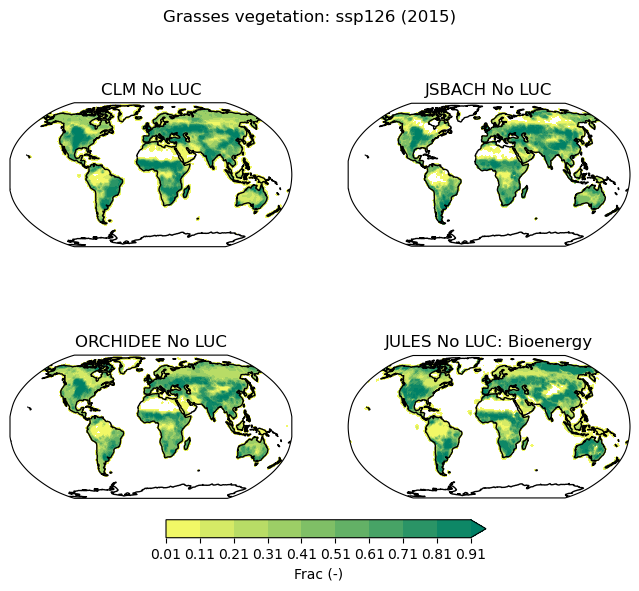

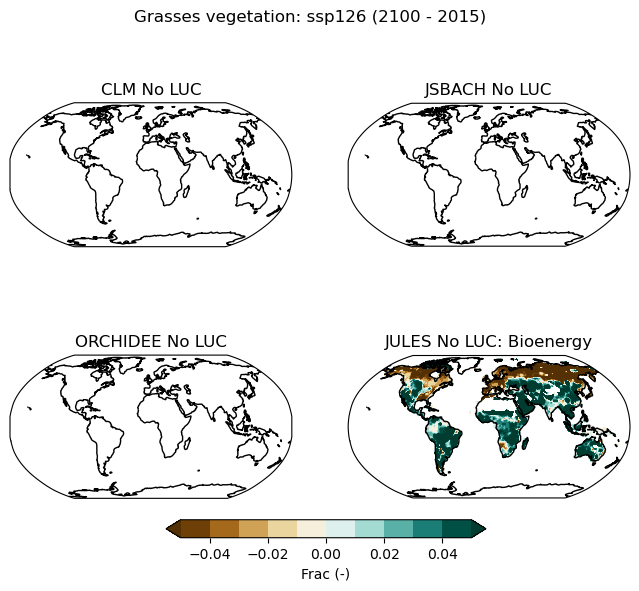

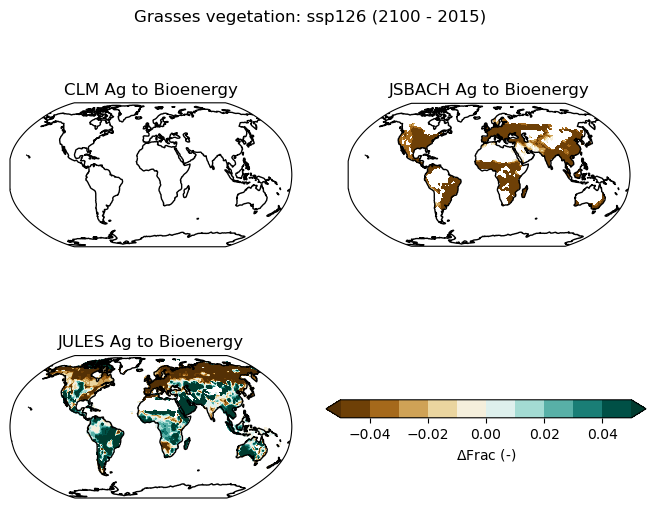

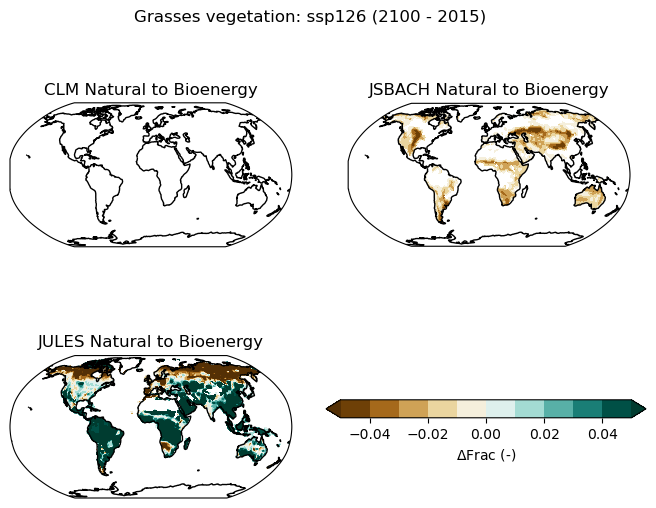

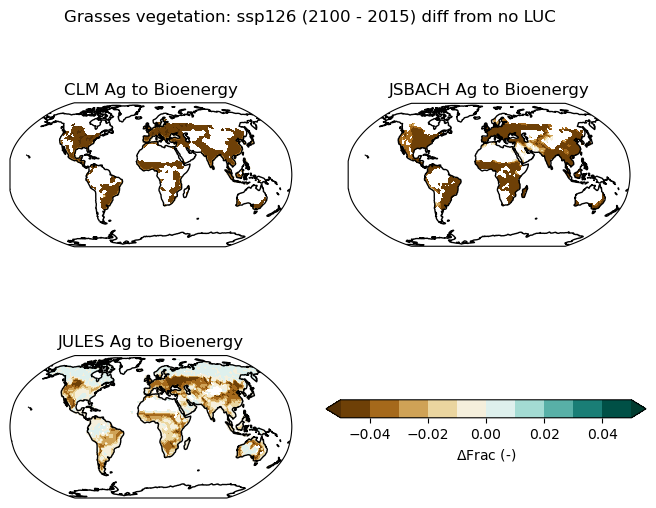

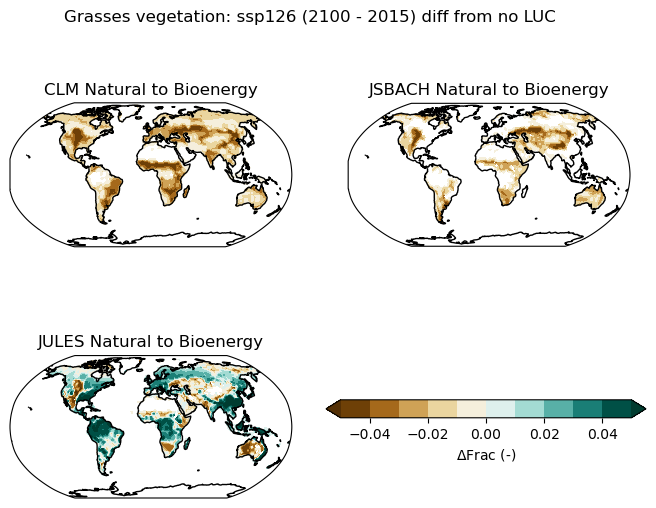

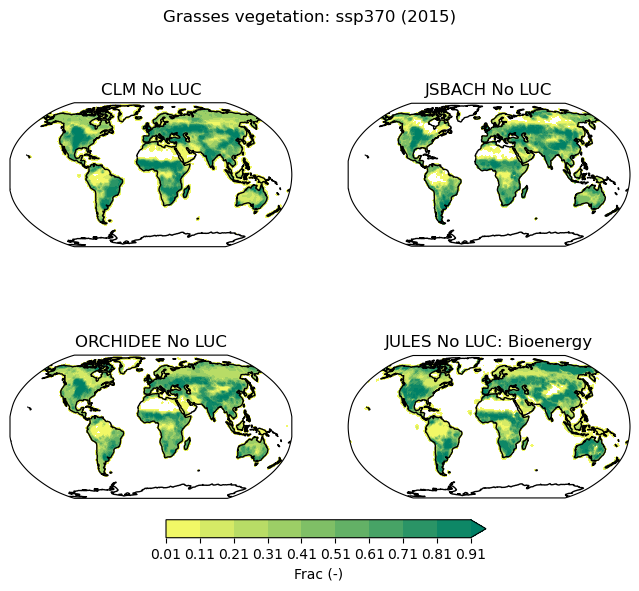

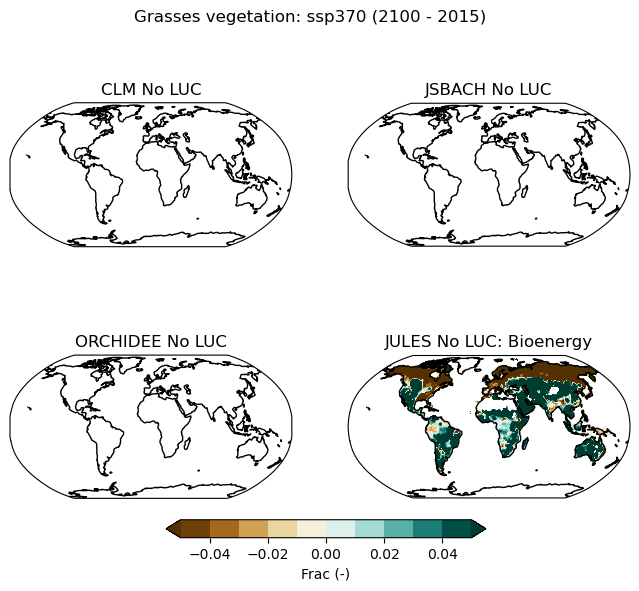

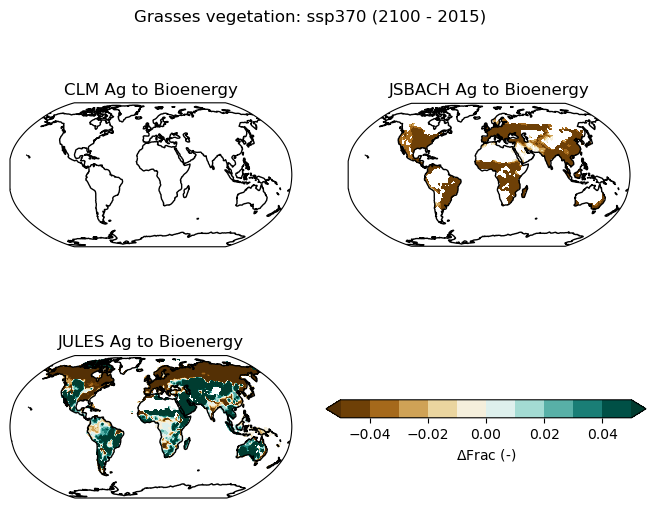

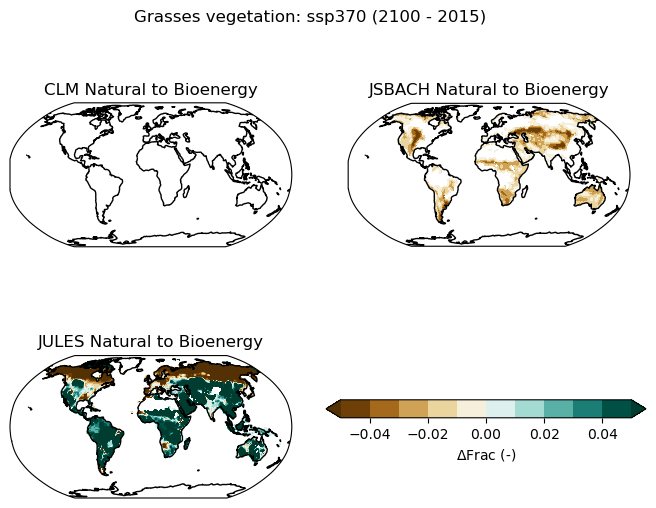

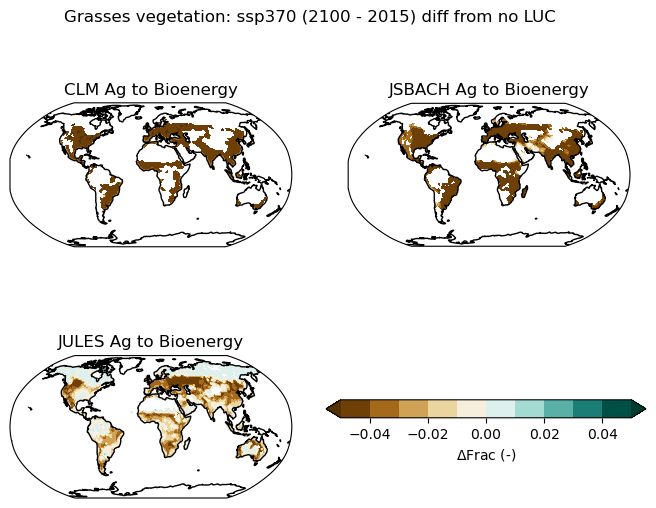

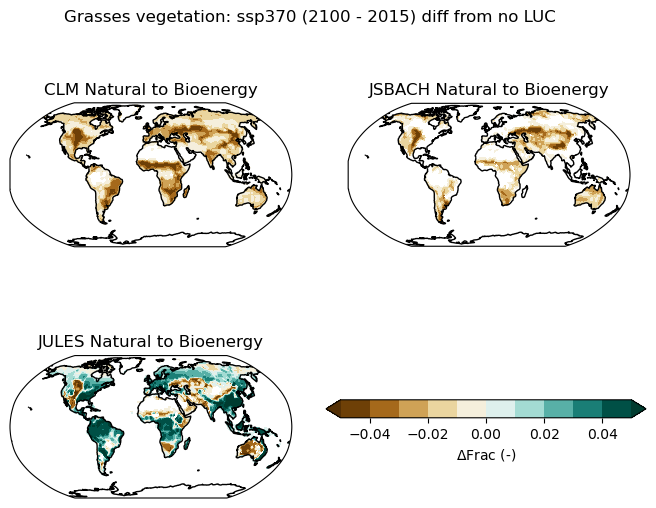

In [14]:
''' Main code:
    This code will generate four* maps and two plots per PFT / LSM / SSP combination,
    reflecting the average across the three ESMS. (4 * 3 * 3 * 2 = 126 .... erm)
    * Only saving maps with a *, other datasets are temporarily created for now 
    but not mapped *
    Map 1*: Aggregated PFTs in 2015 (Woody veg, Grassy veg, Bioenergy): No LUC
        Files named: pft_woody_'+ssp+'_noluc --> woody, grass, bio
    Map 2: Aggregated PFTs in 2100: No LUC
    Map 3*: Map 2 - Map 1 (Climate effect on PFTs)
    Map 4: Aggregated PFTs in 2100: LUC scenario
    Map 5*: Map 4 - Map 1 (LUC scenario change over time)
    Map 6*: Map 5 - Map 3: (Equivalent to [Map 4 - Map 1] - [Map 2 - Map 1]) (Land use effect)
    Plot 1: Time series of aggregated PFTs with no LUC
    Plot 2: Time series of aggregated PFTs with LUC - Plot 1
'''

# Choice 1: which PFTs to map
#0: Woody
#1: Grasses
#2: Bioenergy
pft_to_map=1
# Choice 2: Which land use scenarios to map (no luc are always done)
#2: agtobio
#3: nattobio
#4: agtonat
#5: agtoaff
#6: nattoaff
LUstart=2
LUend=3

MODELS=['clm','jsbach','jules','orchidee']
lsm_name=['CLM','JSBACH','JULES','ORCHIDEE']
nMODELS=len(MODELS)
LANDUSES=['noluc','nolucbio','agtobio','nattobio','agtonat', 'agtoaff' , 'nattoaff']
landuse_name=['No LUC','No LUC: Bioenergy','Ag to Bioenergy', \
              'Natural to Bioenergy', 'Ag to Ref', 'Ag to Aff', 'Natural to Aff']
SSPS=['ssp126','ssp370']
VARIABLES=['cVeg','cSoil','cProduct','cLitter','cTot']
MAPS=['map1','map3','map5','map6']
PFTS=['Woody','Grasses','Bioenergy','Bare Soil']

# PFTs in 2015 
PFT_MAP_2015 = {ssp: {landuse: {pft: {lsm_mod: [] for lsm_mod in MODELS} 
                  for pft in PFTS} for landuse in LANDUSES} for ssp in SSPS}
# PFTs in 2100
endyear=2100
PFT_MAP_END = {ssp: {landuse: {pft: {lsm_mod: [] for lsm_mod in MODELS} 
                  for pft in PFTS} for landuse in LANDUSES} for ssp in SSPS}

PFT_PLOT = {ssp: {landuse: {pft: {lsm_mod: [] for lsm_mod in MODELS} 
                  for pft in PFTS} for landuse in LANDUSES} for ssp in SSPS}

landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
landuse_exists['jules']['noluc'] = False
#landuse_exists['clm']['nolucaff'] = False
landuse_exists['clm']['nolucbio'] = False
landuse_exists['jsbach']['agtonat'] = False
landuse_exists['jsbach']['nattoaff'] = False
#landuse_exists['jsbach']['nolucaff'] = False
landuse_exists['jsbach']['nolucbio'] = False
landuse_exists['orchidee']['agtobio'] = False
landuse_exists['orchidee']['agtonat'] = False
landuse_exists['orchidee']['nattobio'] = False
#landuse_exists['orchidee']['nolucaff'] = False
landuse_exists['orchidee']['nolucbio'] = False

for landuse in LANDUSES:
    
    for ssp in SSPS[0:2]:

        for lsm in MODELS:  
            if landuse_exists[lsm][landuse]:
                #print(landuse,ssp,lsm)           
                pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+lsm+'_fracs_2015_'+ssp+'_'+landuse+'.pkl', \
                              '/bdd/ESM2025/WP10/analysis/files/'+lsm+'_fracs_'+str(endyear)+'_'+ssp+'_'+landuse+'.pkl', \
                              '/bdd/ESM2025/WP10/analysis/files/'+lsm+'_fracs_plot_'+ssp+'_'+landuse+'.pkl']

                land_fraction,lons,lats = get_lsm_data(lsm)

                #Start here: Read the data from pickle files or from the function
                if Path(pickle_file[1]).is_file():
                    # file exists, we can skip a bunch of steps:
                    #print('read pickle files',pickle_file[0])
                    with open(Path(pickle_file[0]), 'rb') as f1:
                        fracs_2015 = pickle.load(f1)
                    with open(Path(pickle_file[1]), 'rb') as f2:
                        fracs_end = pickle.load(f2)
                    with open(Path(pickle_file[2]), 'rb') as f3:    
                        plotdata = pickle.load(f3)  
                
                else:
                    # returns data for map 1, 2, and plot 1
                    if lsm=='jules':
                        fracs_2015, fracs_end, plotdata = jules_fracs(landuse,ssp,endyear,True)
                    elif lsm=='clm':
                        fracs_2015, fracs_end, plotdata = clm_fracs(landuse,ssp,endyear,True)
                    elif lsm=='jsbach':
                        fracs_2015, fracs_end, plotdata = jsbach_fracs(landuse,ssp,endyear,True)
                    elif lsm=='orchidee':
                        fracs_2015, fracs_end, plotdata = orchidee_fracs(landuse,ssp,endyear,True)                        
                    
                    with open(Path(pickle_file[0]), 'wb') as f1:
                        pickle.dump(fracs_2015, f1)
                    with open(Path(pickle_file[1]), 'wb') as f2:
                        pickle.dump(fracs_end, f2)
                    with open(Path(pickle_file[2]), 'wb') as f3:
                        pickle.dump(plotdata, f3)
  
                for j in range(0,4):
                    PFT_MAP_2015[ssp][landuse][PFTS[j]][lsm]=fracs_2015[j,:,:]
                    PFT_MAP_END[ssp][landuse][PFTS[j]][lsm]=fracs_end[j,:,:]
                    PFT_PLOT[ssp][landuse][PFTS[j]][lsm]=plotdata[:,j]
                             
                #print(np.min(fracs_2015[0,:,:]),np.max(fracs_2015[0,:,:]))        
                del(land_fraction,fracs_2015,fracs_end,plotdata)


imap=0
for pft in PFTS[pft_to_map:pft_to_map+1]:
    
    for ssp in SSPS[0:2]:

        imap=0
        for map in MAPS:
            #Maps 1 and 3: five panel plots, one page.
            if map=='map1' or map=='map3':
                mp_fig,mp_axes=plt.subplots(nrows=2,ncols=2,
                                subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                                figsize=(8,6))   
                pltname='/bdd/ESM2025/WP10/maps/pft_'+pft+'_'+ssp+'_'+map+'_'+str(endyear)+'.png'
                # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
                mp_axes=mp_axes.flatten()
                ax_ind=0
                for i1 in range(2):
                    landuse=LANDUSES[i1]
                    for i0 in range(nMODELS):
                        lsm=MODELS[i0] 
                        if landuse_exists[lsm][landuse]:
                            land_fraction,lons,lats = get_lsm_data(lsm)
                            if map=='map1':
                                maparray = np.array(PFT_MAP_2015[ssp][landuse][pft][lsm])
                            else:
                                maparray = np.array(PFT_MAP_END[ssp][landuse][pft][lsm]) - \
                                        np.array(PFT_MAP_2015[ssp][landuse][pft][lsm])
                            if lsm!='jsbach':
                                maparray*=land_fraction
                            if map=='map1':
                                cs = make_map1(lsm_name[i0],landuse_name[i1],mp_axes,ax_ind,np.array(lons),np.array(lats),\
                                               maparray)
                            else:
                                cs = make_map3(lsm_name[i0],landuse_name[i1],mp_axes,ax_ind,np.array(lons),np.array(lats),\
                                                maparray)                                
                            #print(landuse,lsm,'make',map,' for axes',ax_ind)
                            ax_ind+=1
                            del(maparray)
                            
                #mp_fig.delaxes(mp_axes[5])    

                # Adjust the location of the subplots on the page to make room for the colorbar
                #mp_fig.subplots_adjust(bottom=0.2, top=0.9, left=0.1, right=0.9,
                #                           wspace=0.02, hspace=0.04)
                # Add a colorbar axis at the bottom of the graph
                cbar_ax = mp_fig.add_axes([0.32, 0.10, 0.4, 0.03])
                # Draw the colorbar
                cbar=mp_fig.colorbar(cs, cax=cbar_ax,orientation='horizontal',
                                    label='Frac (-)' )
                # Add a big title at the top
                print('save the plot:',pltname)
                if map=='map1':
                    plt.suptitle(pft+' vegetation: '+ssp+' (2015)')
                else:
                    plt.suptitle(pft+' vegetation: '+ssp+' ('+str(endyear)+' - 2015)')                    
                plt.savefig(pltname,format="png", dpi=400)
                #plt.close()
                del(cs,mp_fig,mp_axes)


            #Maps 5 and 6: four panel plots, save a new plot for each land use scenario
            else:

                for i1 in range(LUstart,LUend+1):
                    landuse=LANDUSES[i1]
                    pltname='/bdd/ESM2025/WP10/maps/pft_'+pft+ \
                            '_'+ssp+'_'+landuse+'_'+map+'_'+str(endyear)+'.png'

                    mp_fig,mp_axes=plt.subplots(nrows=2,ncols=2,
                                    subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                                    figsize=(8,6))   
                    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
                    mp_axes=mp_axes.flatten()
                    ax_ind=0

                    for i0 in range(nMODELS):
                        lsm=MODELS[i0]  
                        if landuse_exists[lsm][landuse]:
                            land_fraction,lons,lats = get_lsm_data(lsm)
                            if map=='map5':
                                maparray = np.array(PFT_MAP_END[ssp][landuse][pft][lsm]) - \
                                           np.array(PFT_MAP_2015[ssp][landuse][pft][lsm])
                            else:
                                if lsm=='jules':
                                    if landuse=='agtobio' or landuse=='nattobio':
                                        maparray = (np.array(PFT_MAP_END[ssp][landuse][pft][lsm]) - \
                                                   np.array(PFT_MAP_2015[ssp][landuse][pft][lsm]) - \
                                                   (np.array(PFT_MAP_END[ssp]['nolucbio'][pft][lsm]) - \
                                                   np.array(PFT_MAP_2015[ssp]['nolucbio'][pft][lsm]))) * land_fraction
#                                    else:
#                                        maparray = (np.array(PFT_MAP_END[ssp][landuse][pft][lsm]) - \
#                                                   np.array(PFT_MAP_2015[ssp][landuse][pft][lsm]) - \
#                                                   (np.array(PFT_MAP_END[ssp]['nolucaff'][pft][lsm]) - \
#                                                   np.array(PFT_MAP_2015[ssp]['nolucaff'][pft][lsm]))) * land_fraction
                                elif lsm=='clm':
                                    maparray = np.array(PFT_MAP_2015[ssp][landuse][pft][lsm]) - \
                                               np.array(PFT_MAP_2015[ssp]['noluc'][pft][lsm]) 
                                else:
                                    maparray = np.array(PFT_MAP_END[ssp][landuse][pft][lsm]) - \
                                               np.array(PFT_MAP_2015[ssp][landuse][pft][lsm]) - \
                                               (np.array(PFT_MAP_END[ssp]['noluc'][pft][lsm]) - \
                                               np.array(PFT_MAP_2015[ssp]['noluc'][pft][lsm]))
                            if lsm!='jsbach':
                                maparray*=land_fraction
                            cs = make_map3(lsm_name[i0],landuse_name[i1],mp_axes,ax_ind,np.array(lons),np.array(lats),\
                                            maparray)                               
                            #print(landuse,lsm,'make',map,' for axes',ax_ind)
                            ax_ind+=1
                            del(maparray)
                
                    if (ax_ind<4): 
                        mp_fig.delaxes(mp_axes[ax_ind])
                        if (ax_ind==2):
                            mp_fig.delaxes(mp_axes[ax_ind+1])

                    # Adjust the location of the subplots on the page to make room for the colorbar
                    #mp_fig.subplots_adjust(bottom=0.2, top=0.9, left=0.1, right=0.9,
                    #                       wspace=0.02, hspace=0.04)
                    # Add a colorbar axis at the bottom of the graph
                    if (ax_ind==4):
                        cbar_ax = mp_fig.add_axes([0.32, 0.10, 0.4, 0.03])                        
                    elif (ax_ind==2):
                        #Place it bottom center
                        cbar_ax = mp_fig.add_axes([0.32, 0.40, 0.4, 0.03])
                    elif (ax_ind==3):
                        #Bottom right
                        cbar_ax = mp_fig.add_axes([0.52, 0.30, 0.4, 0.03])
                    
                        
                        
                    # Draw the colorbar
                    cbar=mp_fig.colorbar(cs, cax=cbar_ax,orientation='horizontal',
                                        label=r'$\Delta$Frac (-)' )
                    # Add a big title at the top
                    print('save the plot:',pltname)
                    if map=='map5':
                        plt.suptitle(pft+' vegetation: '+ssp+' ('+str(endyear)+' - 2015)')
                    else:
                        plt.suptitle(pft+' vegetation: '+ssp+' ('+str(endyear)+' - 2015) diff from no LUC')                       
                    plt.savefig(pltname,format="png", dpi=400)    
                    #plt.close()
                    del(cs,mp_fig,mp_axes)
            imap+=0

In [ ]:
            #Name the pickle files
            my_file1=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_2015_'+ssp+'_nolucbio.pkl')
            my_file2=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_2100_'+ssp+'_nolucbio.pkl')
            my_file3=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_plot_'+ssp+'_nolucbio.pkl')
            my_file4=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_2015_'+ssp+'_nolucaff.pkl')
            my_file5=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_2100_'+ssp+'_nolucaff.pkl')
            my_file6=Path('/bdd/ESM2025/WP10/analysis/files/jules_fracs_plot_'+ssp+'_nolucaff.pkl')

            #Read the data from pickle files or from the function
            if my_file4.is_file():
            # file exists, we can skip a bunch of steps:
                print('read pickle files',my_file1)
                with open(my_file1, 'rb') as f1:
                    fracs_2015_nolucbio = pickle.load(f1)
                with open(my_file2, 'rb') as f2:
                    fracs_2100_nolucbio = pickle.load(f2)
                with open(my_file3, 'rb') as f3:    
                    plotdata_nolucbio = pickle.load(f3)  
                with open(my_file4, 'rb') as f4:
                    fracs_2015_nolucaff = pickle.load(f4)
                with open(my_file5, 'rb') as f5:
                    fracs_2100_nolucaff = pickle.load(f5)
                with open(my_file6, 'rb') as f6:    
                    plotdata_nolucaff = pickle.load(f6)   
            else:
                # returns data for map 1, 2, and plot 1
                fracs_2015_nolucbio, fracs_2100_nolucbio, plotdata_nolucbio = jules_fracs('nolucbio',ssp,True)
                fracs_2015_nolucaff, fracs_2100_nolucaff, plotdata_nolucaff = jules_fracs('nolucaff',ssp,True)
                with open(my_file1, 'wb') as f1:
                    pickle.dump(fracs_2015_nolucbio, f1)
                with open(my_file2, 'wb') as f2:
                    pickle.dump(fracs_2100_nolucbio, f2)
                with open(my_file3, 'wb') as f3:
                    pickle.dump(plotdata_nolucbio, f3)
                with open(my_file4, 'wb') as f4:
                    pickle.dump(fracs_2015_nolucaff, f4)
                with open(my_file5, 'wb') as f5:
                    pickle.dump(fracs_2100_nolucaff, f5)
                with open(my_file6, 'wb') as f6:
                    pickle.dump(plotdata_nolucaff, f6)

        elif lsm=='clm':
            if my_file3.is_file():
            # file exists, we can skip a bunch of steps:
                print('read pickle files',my_file1)
                with open(my_file1, 'rb') as f1:
                    fracs_2015_noluc= pickle.load(f1)
                with open(my_file2, 'rb') as f2:
                    fracs_2100_noluc = pickle.load(f2)
                with open(my_file3, 'rb') as f3:    
                    plotdata_noluc = pickle.load(f3)  
            else:
                # returns data for map 1, 2, and plot 1
                fracs_2015_noluc, fracs_2100_noluc, plotdata_noluc = clm_fracs('noluc',ssp,True)
                with open(my_file1, 'wb') as f1:
                    pickle.dump(fracs_2015_noluc, f1)
                with open(my_file2, 'wb') as f2:
                    pickle.dump(fracs_2100_noluc, f2)
                with open(my_file3, 'wb') as f3:
                    pickle.dump(plotdata_noluc, f3)
        
        elif lsm=='orchidee':
            if my_file3.is_file():
            # file exists, we can skip a bunch of steps:
                print('read pickle files',my_file1)
                with open(my_file1, 'rb') as f1:
                    fracs_2015_noluc= pickle.load(f1)
                with open(my_file2, 'rb') as f2:
                    fracs_2100_noluc = pickle.load(f2)
                with open(my_file3, 'rb') as f3:    
                    plotdata_noluc = pickle.load(f3)  
            else:
                # returns data for map 1, 2, and plot 1
                fracs_2015_noluc, fracs_2100_noluc, plotdata_noluc = orchidee_fracs('noluc',ssp,True)
                with open(my_file1, 'wb') as f1:
                    pickle.dump(fracs_2015_noluc, f1)
                with open(my_file2, 'wb') as f2:
                    pickle.dump(fracs_2100_noluc, f2)
                with open(my_file3, 'wb') as f3:
                    pickle.dump(plotdata_noluc, f3)

        elif lsm=='jsbach':
            if my_file3.is_file():
            # file exists, we can skip a bunch of steps:
                print('read pickle files',my_file1)
                with open(my_file1, 'rb') as f1:
                    fracs_2015_noluc= pickle.load(f1)
                with open(my_file2, 'rb') as f2:
                    fracs_2100_noluc = pickle.load(f2)
                with open(my_file3, 'rb') as f3:    
                    plotdata_noluc = pickle.load(f3)  
            else:
                # returns data for map 1, 2, and plot 1
                fracs_2015_noluc, fracs_2100_noluc, plotdata_noluc = jsbach_fracs('noluc',ssp,True)                           
                with open(my_file1, 'wb') as f1:
                    pickle.dump(fracs_2015_noluc, f1)
                with open(my_file2, 'wb') as f2:
                    pickle.dump(fracs_2100_noluc, f2)
                with open(my_file3, 'wb') as f3:
                    pickle.dump(plotdata_noluc, f3)
        
        for j in range(0,3):
            if lsm=='jules':
                PFT_MAP_2015[ssp]['noluc'][PFTS[j]][lsm]=fracs_2015_nolucbio[j,:,:]
                PFT_MAP_2100[ssp]['noluc'][PFTS[j]][lsm]=fracs_2100_nolucbio[j,:,:]
                PFT_PLOT[ssp]['noluc'][PFTS[j]][lsm]=plotdata_nolucbio[:,j]
                PFT_MAP_2015[ssp]['nolucaff'][PFTS[j]][lsm]=fracs_2015_nolucaff[j,:,:]
                PFT_MAP_2100[ssp]['nolucaff'][PFTS[j]][lsm]=fracs_2100_nolucaff[j,:,:]
                PFT_PLOT[ssp]['nolucaff'][PFTS[j]][lsm]=plotdata_nolucaff[:,j]                
            else:
                PFT_MAP_2015[ssp]['noluc'][PFTS[j]][lsm]=fracs_2015_noluc[j,:,:]
                PFT_MAP_2100[ssp]['noluc'][PFTS[j]][lsm]=fracs_2100_noluc[j,:,:]
                PFT_PLOT[ssp]['noluc'][PFTS[j]][lsm]=plotdata_noluc[:,j]        
        print(np.min(fracs_2015_noluc[0,:,:]),np.max(fracs_2015_noluc[0,:,:]))        
